# **ANN 12 – Write a Python program to implement a Convolutional Neural Network (CNN) using TensorFlow/Keras on the MNIST dataset.**

In [5]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
def plot_training_history(history):
    """Plots accuracy and loss from the Keras history object."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    ax2.grid(True)
    plt.show()

In [3]:
def plot_misclassified_images(X_test, y_test, y_pred, n=10):
    """Shows a sample of misclassified images."""
    misclassified_indices = np.where(y_pred != y_test)[0]
    sample_indices = np.random.choice(misclassified_indices, size=min(n, len(misclassified_indices)), replace=False)
    
    plt.figure(figsize=(12, 5))
    for i, idx in enumerate(sample_indices):
        plt.subplot(2, 5, i + 1)
        plt.imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
        plt.title(f"True: {y_test[idx]}, Pred: {y_pred[idx]}")
        plt.xticks([])
        plt.yticks([])
    plt.suptitle("Sample of Misclassified Images", fontsize=16)
    plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


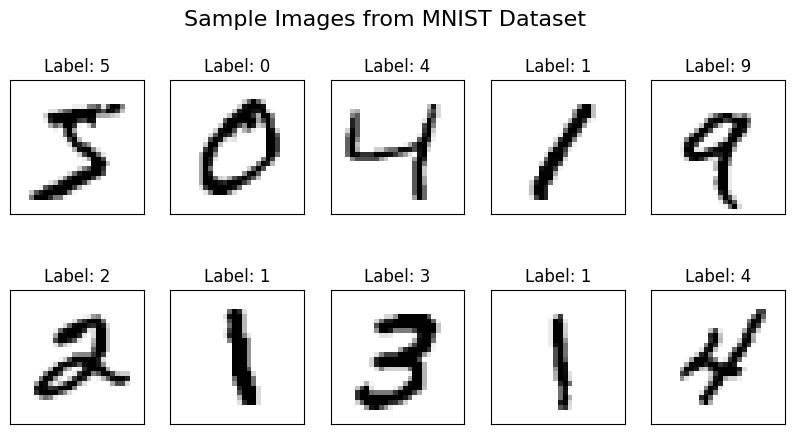

c:\Users\omshi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)


--- Starting Model Training ---
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9461 - loss: 0.1794 - val_accuracy: 0.9845 - val_loss: 0.0506
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9838 - loss: 0.0525 - val_accuracy: 0.9853 - val_loss: 0.0410
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9891 - loss: 0.0366 - val_accuracy: 0.9882 - val_loss: 0.0339
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9911 - loss: 0.0288 - val_accuracy: 0.9899 - val_loss: 0.0319
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9926 - loss: 0.0225 - val_accuracy: 0.9894 - val_loss: 0.0332


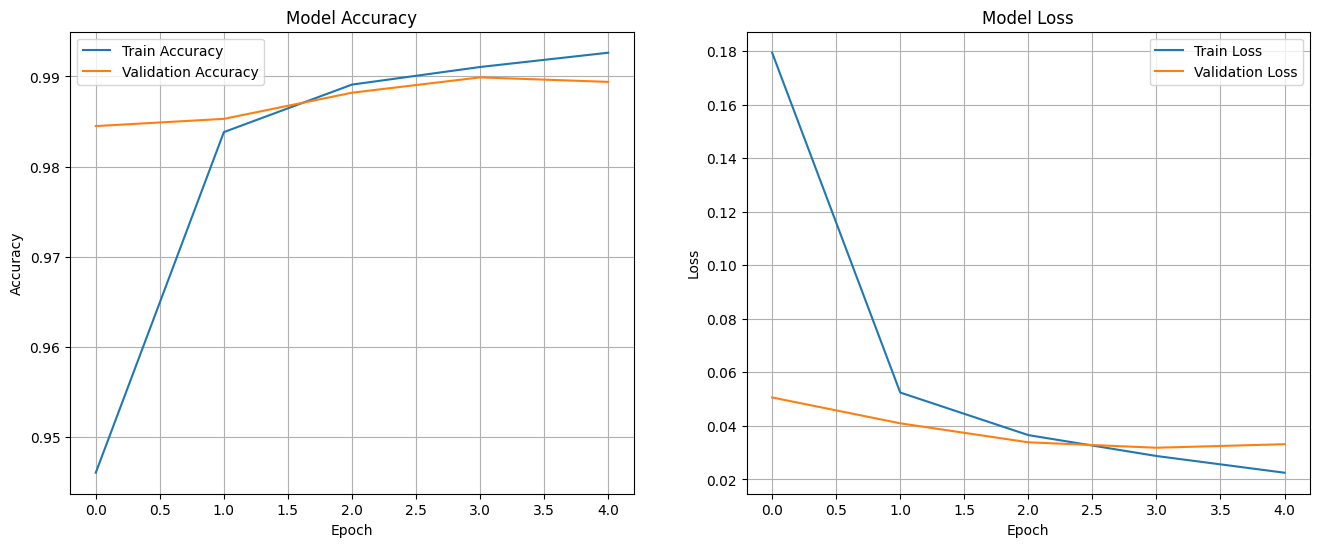


--- Final Model Evaluation on Test Data ---
Test Accuracy: 0.9894
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


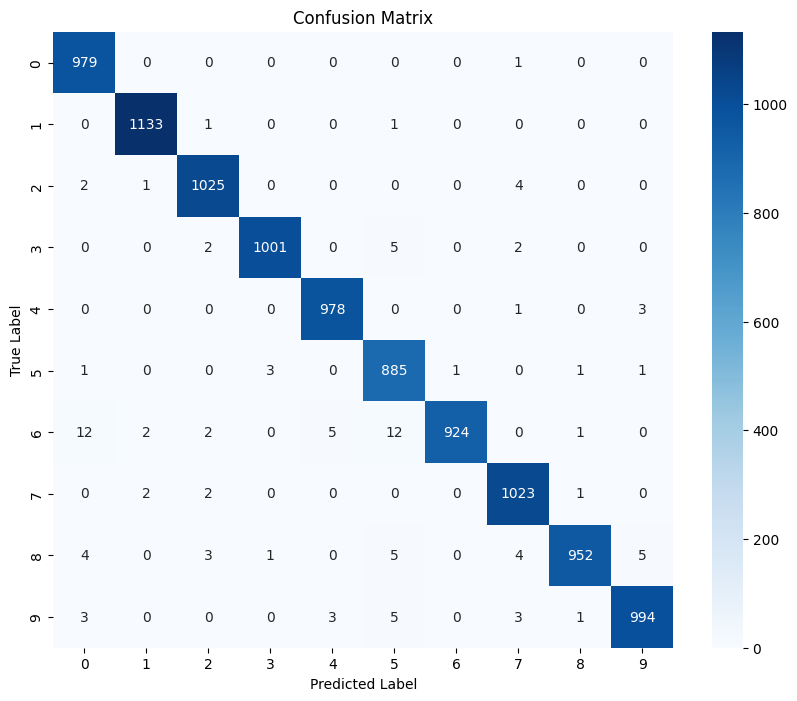

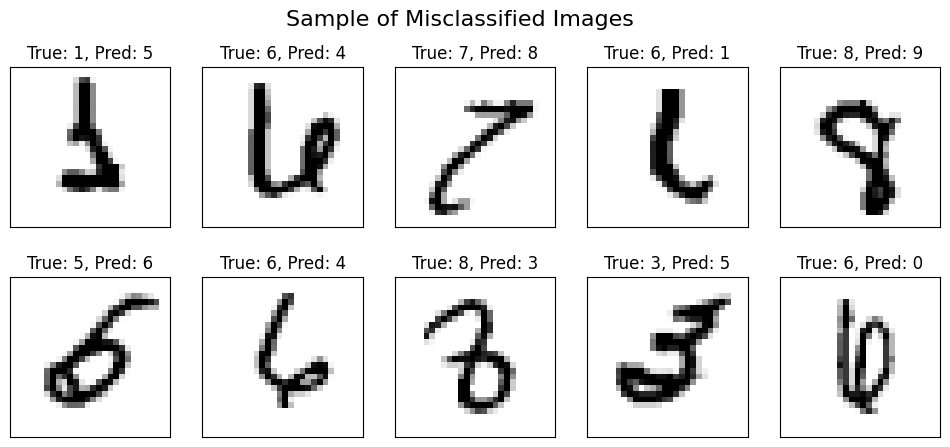

In [4]:
# --- Main execution block ---

if __name__ == "__main__":
    # 1. Load and explore the MNIST dataset
    mnist = tf.keras.datasets.mnist
    (X_train, y_train), (X_test, y_test) = mnist.load_data()

    print(f"Training data shape: {X_train.shape}")
    print(f"Test data shape: {X_test.shape}")

    # Display some sample images
    plt.figure(figsize=(10, 5))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(X_train[i], cmap='gray_r')
        plt.title(f"Label: {y_train[i]}")
        plt.xticks([])
        plt.yticks([])
    plt.suptitle("Sample Images from MNIST Dataset", fontsize=16)
    plt.show()

    # 2. Preprocess the data
    # Normalize pixel values to be between 0 and 1
    X_train, X_test = X_train / 255.0, X_test / 255.0
    # Add a channel dimension for the Conv2D layer
    X_train = X_train[..., tf.newaxis]
    X_test = X_test[..., tf.newaxis]

    # 3. Define the CNN model
    model = tf.keras.Sequential([
        # Convolutional base
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        # Classifier head
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    
    # 4. Compile the model
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    model.summary()

    # 5. Train the model
    print("\n--- Starting Model Training ---")
    history = model.fit(X_train, y_train, 
                        epochs=5, 
                        batch_size=64,
                        validation_data=(X_test, y_test),
                        verbose=1)
    
    # 6. Evaluate the model and visualize results
    plot_training_history(history)
    
    print("\n--- Final Model Evaluation on Test Data ---")
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f'Test Accuracy: {test_acc:.4f}')
    
    # Generate predictions to create a confusion matrix and find errors
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # Plot a few misclassified examples
    plot_misclassified_images(X_test, y_test, y_pred)